In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from models._config import *
from models.LSTM import BiLSTM
from models.UNET import UNet, U2Net
from ex_models.LRP import LRP

# 데이터 로드
def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)


test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_class_dB'


data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snrs_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')

fs = 100e6
epochs = 500

losses = []
best_loss = float('inf')
best_state = None

CEloss = nn.CrossEntropyLoss()
model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms))
model = nn.DataParallel(model).cuda()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
for epoch in range(epochs):
    total_loss = 0.0
    progress = tqdm(range(len(data_dict)), total=len(data_dict), desc=f'Epoch {epoch+1}/{epochs}')
    for batch in progress:
        
        key = f'arr_{batch}'
        data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
        length_batch, snr_batch = lengths_batch[batch], snrs_batch[batch]
        
        pos_data_batch = np.transpose(
            np.array([[d.real, d.imag] for d in [
                highpass_filter(comp(np.where(r[:, 0] > 0, d[:, 0], 0), 
                                    np.where(r[:, 1] > 0, d[:, 1], 0)), 1e6, fs) 
                for d, r in zip(data_batch, relevance_batch)
            ]]), (0, 2, 1)
        )
        
        pos_data_batch = torch.stack([torch.tensor(data.copy(), dtype=torch.float32) for data in pos_data_batch]).cuda()
        pos_data_batch = rnn_utils.pad_sequence(pos_data_batch, batch_first=True)
        
        length_batch = torch.tensor(length_batch, dtype=torch.int64).cpu()
        
        
        output = model(pos_data_batch, length_batch)
        loss = CEloss(output, label_batch.cuda())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        progress.set_postfix({'Batch': f'{batch+1}/{len(data_dict)}', 'Loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(data_dict)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}')
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = model.state_dict()
        torch.save(best_state, f'./ckpts/pwnNoisy/BiLSTM_R>0_fft_best_{best_loss:.4f}.pth')
        if best_loss < 0.002:
            break
    torch.cuda.empty_cache()
torch.save(model.state_dict(), f'./ckpts/pwnNoisy/BiLSTM_R>0_fft_final_{avg_loss:.4f}.pth')


Epoch 1/500:   0%|          | 0/432 [00:00<?, ?it/s]/home/kiwan/anaconda3/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:1870: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '
/home/kiwan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kiwan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
Epoch 1/500:   0%|          | 0/432 [00:00<?, ?it/s]


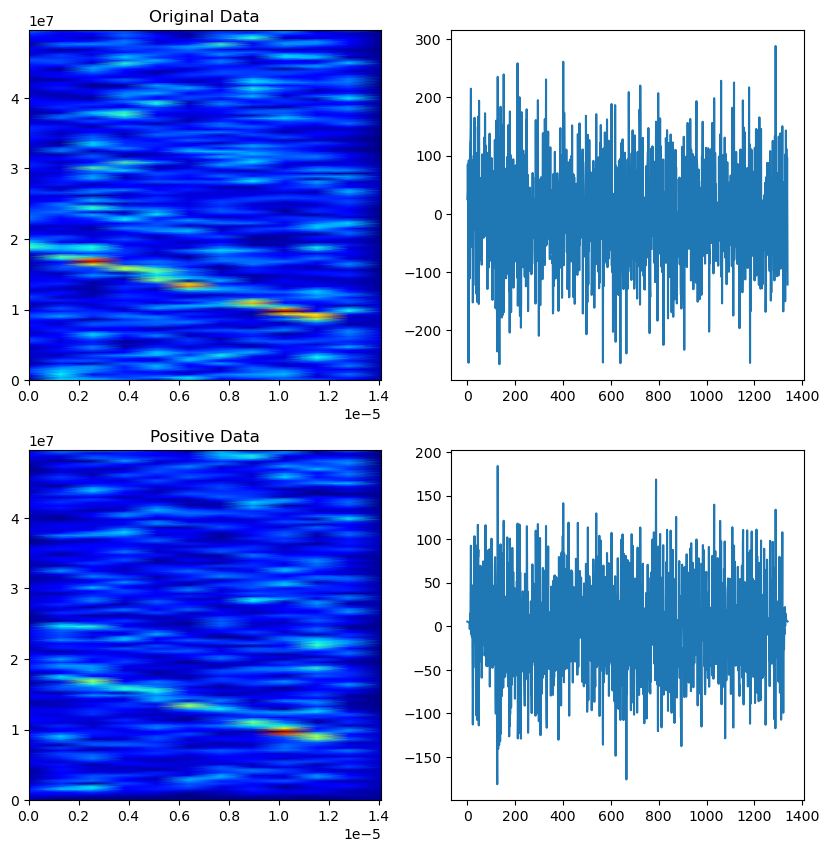

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from models._config import *
from models.LSTM import BiLSTM
from models.UNET import UNet, U2Net
from ex_models.LRP import LRP

# 데이터 로드
def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)


test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_train_class_dB'


data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snrs_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')

fs = 100e6
epochs = 500

losses = []
best_loss = float('inf')
best_state = None

CEloss = nn.CrossEntropyLoss()
model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms))
model = nn.DataParallel(model).cuda()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
for epoch in range(epochs):
    total_loss = 0.0
    progress = tqdm(range(len(data_dict)), total=len(data_dict), desc=f'Epoch {epoch+1}/{epochs}')
    for batch in progress:
        key = f'arr_{batch}'
        data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
        length_batch, snr_batch = lengths_batch[batch], snrs_batch[batch]
        
        pos_data_batch = np.transpose(
            np.array([[d.real, d.imag] for d in [
                highpass_filter(comp(np.where(r[:, 0] > 0, d[:, 0], 0), 
                                    np.where(r[:, 1] > 0, d[:, 1], 0)), 1e6, fs) 
                for d, r in zip(data_batch, relevance_batch)
            ]]), (0, 2, 1)
        )
        
        shuffle = False
        batch_sample = shuffle(list(zip(data_batch, pos_data_batch, length_batch))) if shuffle else zip(data_batch, pos_data_batch, length_batch)
        for data, pos, l in batch_sample:
            fig, axs = plt.subplots(2, 2, figsize=(10, 10))
            data = data[:l]
            pos =   pos[:l]
            f, a, fft = fft_transform(data[:, 0], data[:, 1], fs)
            f, t, Zxx = stft_transform(data[:, 0], data[:, 1], fs)
            
            axs[0, 0].pcolormesh(t, f[:len(f)//2], Zxx[:len(f)//2], shading='gouraud', cmap='jet')
            axs[0, 0].set_title('Original Data')
            axs[0, 1].plot(fft)
            
            ff, aa, ffft = fft_transform(pos[:, 0], pos[:, 1], fs)
            ff, tt, tZxx = stft_transform(pos[:, 0], pos[:, 1], fs)
            axs[1, 0].pcolormesh(tt, ff[:len(ff)//2], tZxx[:len(ff)//2], shading='gouraud', cmap='jet')
            axs[1, 0].set_title('Positive Data')
            axs[1, 1].plot(ffft)
            

            break

        break
    break
#         pos_data_batch = torch.stack([torch.tensor(data.copy(), dtype=torch.float32) for data in pos_data_batch]).cuda()
#         pos_data_batch = rnn_utils.pad_sequence(pos_data_batch, batch_first=True)
        
#         length_batch = torch.tensor(length_batch, dtype=torch.int64).cpu()
        
        
#         output = model(pos_data_batch, length_batch)
#         loss = CEloss(output, label_batch.cuda())
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

#         total_loss += loss.item()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         progress.set_postfix({'Batch': f'{batch+1}/{len(data_dict)}', 'Loss': f'{loss.item():.4f}'})

#     avg_loss = total_loss / len(data_dict)
#     losses.append(avg_loss)
#     print(f'Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}')
    
#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         best_state = model.state_dict()
#         torch.save(best_state, f'./ckpts/pwnNoisy/BiLSTM_R>0_best_{best_loss:.4f}.pth')
#         if best_loss < 0.002:
#             break
#     torch.cuda.empty_cache()
# torch.save(model.state_dict(), f'./ckpts/pwnNoisy/BiLSTM_R>0_final_{avg_loss:.4f}.pth')


In [ ]:
from torch.utils.data import DataLoader
from dataset.LPIdataset import LPIDataset
from models._config import *

test_dir = 'dataset/lpi_testset/'
ockpt = 'ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth'
ckpt = 'ckpts/pwnNoisy/BiLSTM_R>0_best_0.0208.pth'
dataset = LPIDataset(test_dir, waveforms, data_type=datatypes[-1], model_type=modeltypes[0])
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate)
model, lrp = load_models(ckpt, device='cuda')

model.eval()

import torch
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, dataloader, device='cuda'):
    model.to(device)
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for data, labels, lengths, snr, idx in dataloader:
            data = data.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(data, lengths)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate performance metrics
    accuracy = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=waveforms, output_dict=True)

    return {
        "accuracy": accuracy,
        "classification_report": report
    }

# 성능 평가 실행
metrics = evaluate_model(model, dataloader)

# 결과 출력
print(f"Accuracy: {metrics['accuracy']:.4f}")
for label, scores in metrics['classification_report'].items():
    if isinstance(scores, dict):
        print(f"{label}: Precision: {scores['precision']:.4f}, Recall: {scores['recall']:.4f}, F1-Score: {scores['f1-score']:.4f}")


